In [1]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import select_random_json, read_experiment_json, load_properties_bundle, create_folder
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np
import json

In [2]:
results_folder = "../results/TimeSeries/3D"
create_folder(results_folder)

In [3]:
def load_properties_bundle(fn):
    with open(fn, "r") as f:
        return json.load(f)


def get_group_by_p0_P0(bundle, p0_target, P0_target, tol=1e-12):
    """
    Seleciona o bloco correto dentro de properties_mean_bundle.json
    usando simultaneamente p0_value e P0_value.
    """
    for group in bundle["p0_groups"]:
        p0_value = float(group["p0_value"])
        P0_value = float(group["P0_value"])

        if abs(p0_value - p0_target) < tol and abs(P0_value - P0_target) < tol:
            return group

    raise ValueError(f"Não encontrei grupo com p0={p0_target} e P0={P0_target}")

## p(t) SERIES - $p_0$ effects for differents sizes

ValueError: Não encontrei grupo com p0=0.3 e P0=0.2

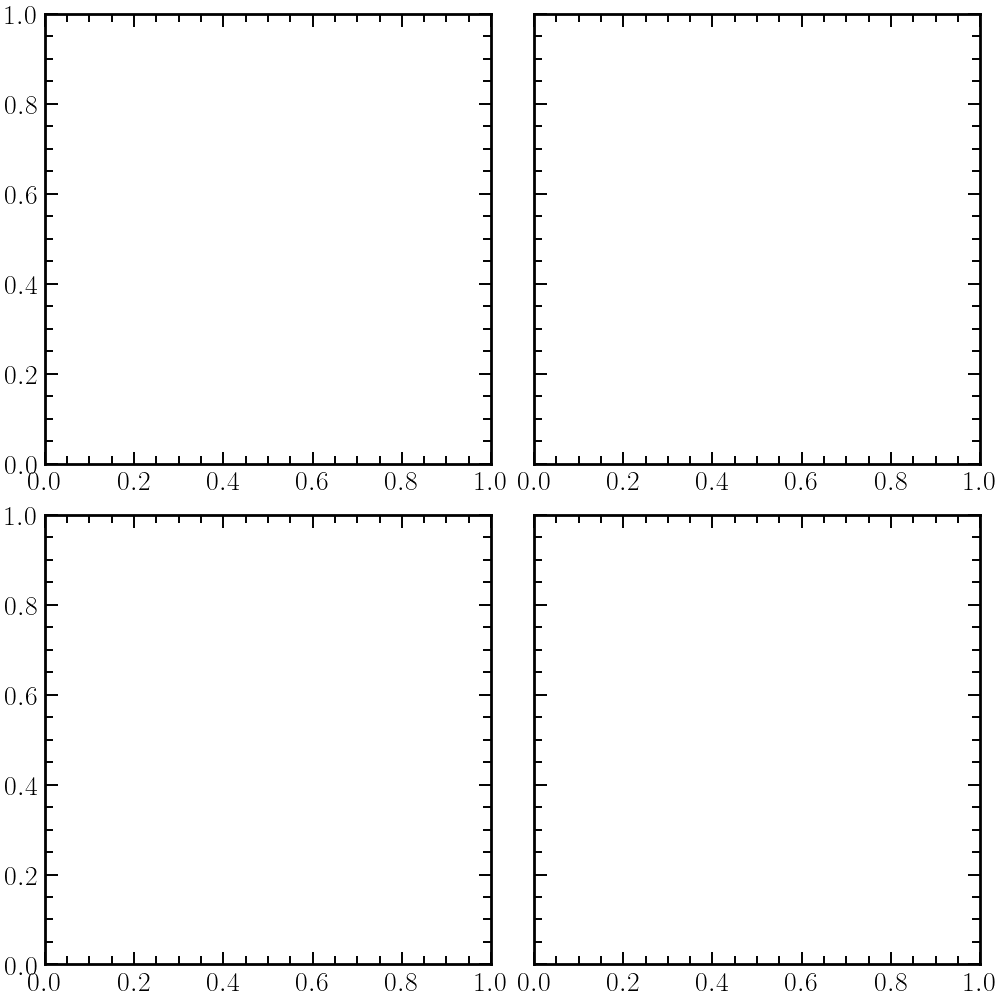

In [7]:
#fT = 0.05
#c = 0.01
fT = 0.022000
c=0.01
L_lst = [256, 256, 512, 1024]
dim = 3
nc = 1
rho = 1.0
base = 5
sw = 300
P0 = 0.2
p0_values = [0.3, 0.7, 1.0]
min_support_fraction = 0.20
min_support_abs = 5
fig, axes = plt.subplots(2, 2, figsize=(2*base, 2*base), constrained_layout=True, sharey=True)
order_mean = 0
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(a)$', r'$(b)$', r'$(c)$']
fs_labels_fig = 30
fs_l_fig = 27

t_max = 0.0

for idx, ax in enumerate(axes.flatten()):
    L = L_lst[idx]
    path = f"../SOP_data/published_dynamic/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{fT:.6e}/c_{c:.6e}/rho_{rho:.4e}/"

    fn = path + "properties_dynamic_bundle.json"
    bundle = load_properties_bundle(fn)

    for idx_p0, p0 in enumerate(p0_values):
        group = get_group_by_p0_P0(bundle, p0_target=p0, P0_target=P0)

        order_block = group["orders"][order_mean]
        data = order_block["data"]
        #data = bundle[p0]["orders"][order_mean]
    
        t = np.asarray(data["time"], dtype=float)
        pt = np.asarray(data["pt_mean"], dtype=float)
        n_per_t = np.asarray(
            data.get("pt_N_per_t", np.full_like(t, order_block.get("N_samples_perc", group["num_samples_total"]))),
            dtype=float,
        )
        n_total = int(group["num_samples_total"])
        min_support = min(n_total, max(min_support_abs, int(np.ceil(min_support_fraction * n_total))))
        mask = n_per_t >= min_support
        if not np.any(mask):
            mask = n_per_t >= np.nanmax(n_per_t)
        t_plot = t[mask]
        pt_plot = pt[mask]
        if t_plot.size:
            t_max = max(t_max, float(np.nanmax(t_plot)))
    
        ax.plot(t_plot, pt_plot, ls='solid',color=colors[idx_p0], label=f'$p_0 = {p0}$')
    
    ax.axhline(pc, color='k', ls='solid')
    ax.set_ylim(0.245, 0.265)
    ax.text(0.08, 0.9, f'$L = {L}$', transform=ax.transAxes , fontsize=fs_l_fig)
    ax.legend()

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.86, 0.10, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

for ax in axes[:,0]:
    ax.set_ylabel(r'$\langle p(t) \rangle_{samples}$')
for ax in axes[1,:]:
    ax.set_xlabel(r'$t$')

#fig.suptitle(f"dim $= {dim}$, $f_T = {fT}$, $n_s = 1$, $c = {c}$", fontsize=30)
plt.savefig(results_folder + f"/pt_multiply_L.pdf", dpi=300)
plt.show()

## p(t) SERIES - $L = 256$ Inicial Fraction activate Effects ($P_0=$[$0.1$, $0.25$, $0.50$, $1.0$]

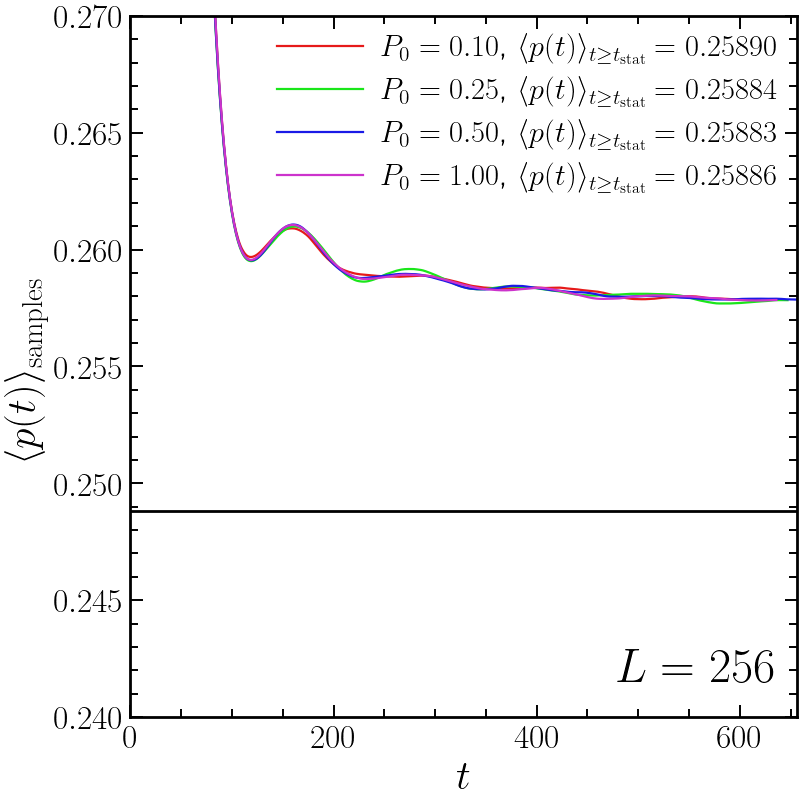

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt


def load_properties_bundle(fn):
    with open(fn, "r") as f:
        return json.load(f)


def get_group_by_p0_P0(bundle, p0_target, P0_target, tol=1e-12):
    """
    Seleciona o bloco correto dentro de properties_mean_bundle.json
    usando simultaneamente p0_value e P0_value.
    """
    for group in bundle["p0_groups"]:
        p0_value = float(group["p0_value"])
        P0_value = float(group["P0_value"])

        if abs(p0_value - p0_target) < tol and abs(P0_value - P0_target) < tol:
            return group

    raise ValueError(f"Não encontrei grupo com p0={p0_target} e P0={P0_target}")


nc, dim = 1, 3
L = 256
c = 0.01

fT = 0.014823
P0_lst = [0.1, 0.25, 0.50, 1.0]
p0 = 0.6
rho = 1 / nc
order_mean = 0
pc = 0.24881182
fs_legend = 22

fn = (
    f"../SOP_data/published/bond_percolation/"
    f"num_colors_{nc}/dim_{dim}/L_{L}/"
    f"fT_constant/fT_{fT:.6e}/c_{c:.6e}/rho_{rho:.4e}/"
    f"properties_mean_bundle.json"
)

bundle = load_properties_bundle(fn)

max_t_global = -np.inf

base = 4
fig, ax = plt.subplots(
    1, 1,
    figsize=(2 * base, 2 * base),
    constrained_layout=True
)

fs_labels_fig = 30
fs_l_fig = 35
fs_labels = 30

for P0 in P0_lst:
    group = get_group_by_p0_P0(bundle, p0_target=p0, P0_target=P0)

    data = group["orders"][order_mean]["data"]
    pmean = group["pc_sop"]["mean"]

    t = np.asarray(data["time"])
    pt = np.asarray(data["pt_mean"])

    max_t_global = max(max_t_global, np.max(t))

    ax.plot(
        t,
        pt,
        "-",
        lw=1.6,
        label=rf'$P_{{\mathrm{{0}}}} = {P0:.2f}$, '
              rf'$p^* = {pmean:.5f}$'
    )

ax.text(
    0.73,
    0.05,
    rf'$L={L}$',
    transform=ax.transAxes,
    fontsize=fs_l_fig
)

ax.axhline(pc, color="k", lw=2.0, ls="solid")

ax.set_xlim(0, max_t_global)
ax.set_ylim(0.24, 0.27)

ax.set_xlabel(r'$t$', fontsize=fs_labels)
ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$', fontsize=fs_labels)

ax.tick_params(axis="both", which="major", labelsize=24)

leg = ax.legend(
    fontsize=fs_legend,
    handlelength=2.8,
    handletextpad=0.6,
    borderpad=0.4,
    labelspacing=0.4
)

for line in leg.get_lines():
    line.set_linewidth(1.6)

plt.savefig(results_folder + f"/L_{L}_fT_{fT:.2f}_c_{c:.2f}_different_P0.pdf", bbox_inches="tight")
plt.show()

In [33]:
f_T = np.linspace(0.001, 0.30, 25)
f_T

array([0.001     , 0.01345833, 0.02591667, 0.038375  , 0.05083333,
       0.06329167, 0.07575   , 0.08820833, 0.10066667, 0.113125  ,
       0.12558333, 0.13804167, 0.1505    , 0.16295833, 0.17541667,
       0.187875  , 0.20033333, 0.21279167, 0.22525   , 0.23770833,
       0.25016667, 0.262625  , 0.27508333, 0.28754167, 0.3       ])

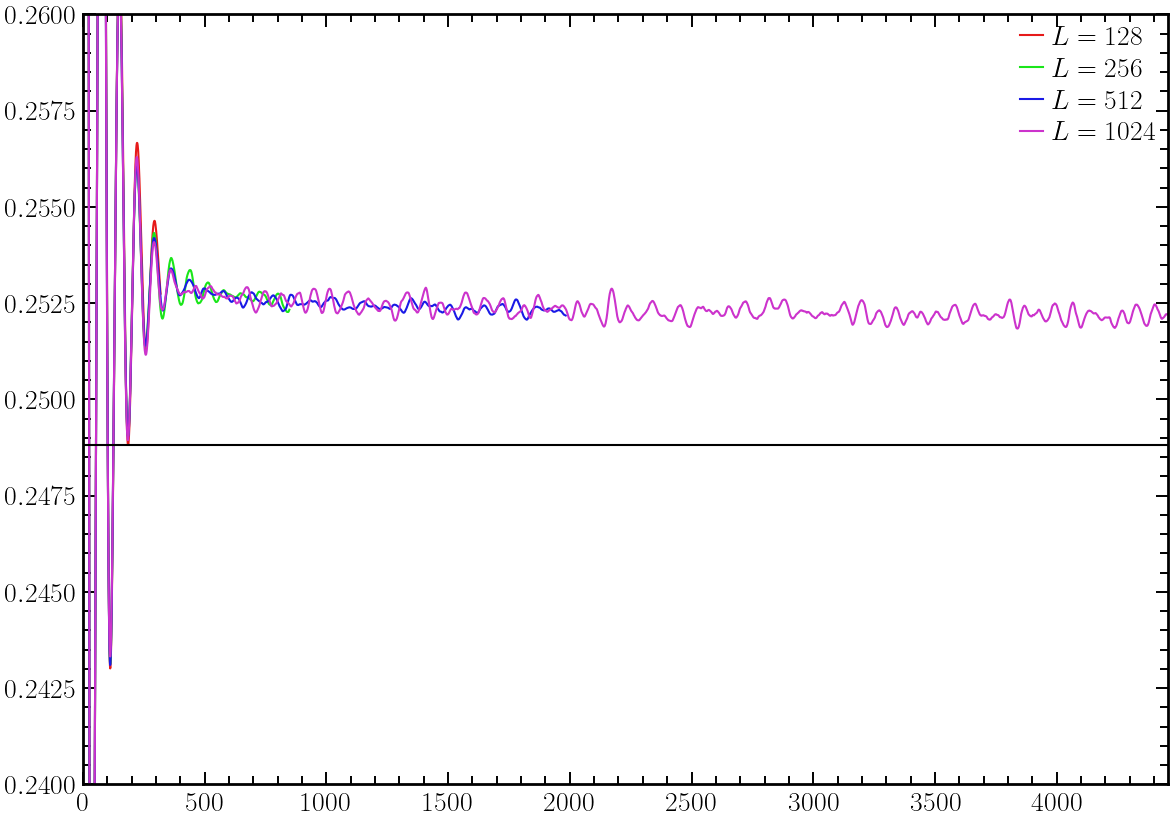

In [ ]:
nc = 1
dim = 3
L_lst = [128, 256, 512, 1024]
fT = 5.0e-02
c = 0.05
rho = 1/nc
pc = 0.24881182

for L in L_lst:
    path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{fT:.6e}/c_{c:.6e}/rho_{rho:.4e}"
    #path = "../SOP_data/published/bond_percolation/num_colors_1/dim_3/L_1024/fT_constant/fT_1.000000e-02/c_1.000000e-02/rho_1.0000e+00"

    fn = path + "/properties_mean_bundle.json"
    bundle = load_properties_bundle(fn)
    p0_val = 1.0
    order_mean = 0
    data = bundle[p0_val]["orders"][order_mean]
    time = data["time"]
    pt_mean = data["pt_mean"]
    plt.plot(time, pt_mean,ls='solid', label=f'$L={L}$')

plt.axhline(y=pc,color='k')
plt.ylim(0.24,0.26)
plt.xlim(min(time),max(time))
plt.legend()
plt.show()



In [2]:
results_folder = "../results/TimeSeries/3D"
folders = [results_folder + "/1_color", results_folder + "/rho"]
for folder in folders:
    create_folder(folder)

results_folder_pt = "../results/TimeSeries/3D/define_pt/"
create_folder(results_folder_pt)

Folder already exists: ../results/TimeSeries/3D/1_color
Folder already exists: ../results/TimeSeries/3D/rho
Folder already exists: ../results/TimeSeries/3D/define_pt/


## EFFECTS P0

[2, 31457, 0.5]
[4, 20971, 0.25]
[8, 10485, 0.125]


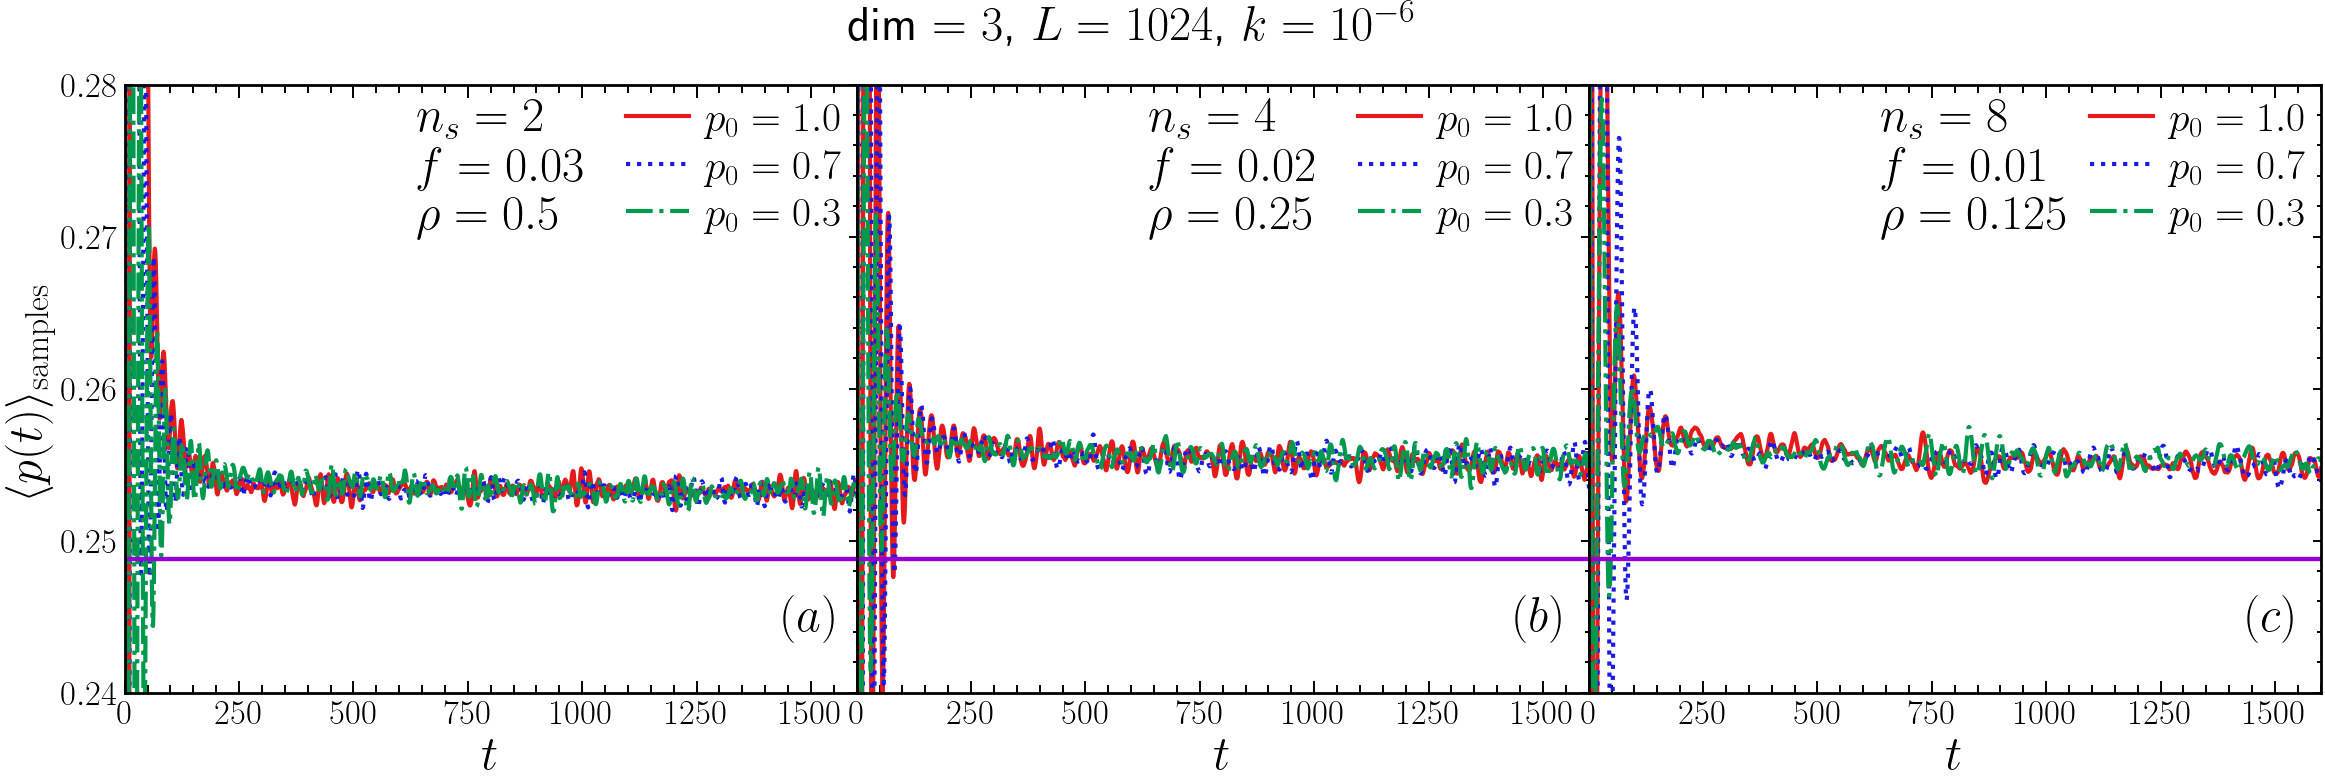

In [83]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================
L = 1024
dim = 3
#nc = 1
#rho = 1 / nc
k = 1.0e-06
#f0 = 0.04

p0_lst = [1.0, 0.7, 0.3]
order_raw = 1
lw = 3.0
fs_label =  35
fs_legend = 30
fs_labels_fig = 35
fs_ticks = 25
fs_title = 35

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]

# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
NT = 41943
# nc, NT, rho
#parms = [[2, int(0.03*L**2), 1/2],[4, int(0.01*L**2), 1/4], [8, int(0.01*L**2), 1/8]]
f0_lst = [0.03, 0.02, 0.01]
L_lst = [256, 512, 1024]
L = 1024
pc = 0.24881182
ls = ['solid', 'dotted', 'dashdot']
base = 8
fig, ax = plt.subplots(1, 3, figsize=(3*base, base), sharey=True, sharex=True,  gridspec_kw={"wspace": 0, "hspace": 0})
fig.subplots_adjust(left=0.08, right=0.995, bottom=0.12, top=0.88, wspace=0)
order_mean = 0

parms = [[2, int(f0_lst[0]*L**2), 1/2],[4, int(f0_lst[1]*L**2), 1/4], [8, int(f0_lst[2]*L**2), 1/8]]

for idx_nc, par in enumerate(parms):
    print(par)
    nc = par[0]
    NT = par[1]
    rho = par[2]
    path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
    bundle_path = path_dir_pub + "properties_mean_bundle.json"
    bundle = load_properties_bundle(bundle_path)

    for idx, p0_val in enumerate(p0_lst):
        data = bundle[p0_val]["orders"][order_mean]
        time = data["time"]
        pt_mean = data["pt_mean"]

        ax[idx_nc].plot(time, pt_mean, lw=lw, ls=ls[idx], color=colors[idx], label=fr"$p_0 = {p0_val:.1f}$")

title = [r'$n_c = 2$', r'$n_c = 4$', r'$n_c = 8$']
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$']

for idx, a in enumerate(ax):
    ns= parms[idx][0]
    NT = parms[idx][1]
    rho = parms[idx][2]
    
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, length=3)

    a.set_ylim(0.24, 0.28)
    a.set_xlim(0, 1600)
    a.axhline(y=pc, color="darkviolet", lw=1.05*lw)

    a.set_xlabel(r"$t$", fontsize=fs_label)
    a.legend(fontsize=fs_legend, handlelength=1.5)
    a.text(0.9, 0.10, labels_fig[idx], transform=a.transAxes, fontsize=fs_labels_fig)
    a.text(0.4, 0.76,f'$n_s = {ns}$' + "\n" + f"$f = {f0_lst[idx]}$" + "\n" + f"$\\rho = {rho}$",
           transform=a.transAxes, fontsize=fs_labels_fig)
    a.tick_params(axis='both', labelsize=fs_ticks)

    # só o primeiro painel mostra labels no eixo y
    if idx == 0:
        a.tick_params(axis='y', which='major', labelleft=True)
    else:
        a.tick_params(axis='y', which='both', labelleft=False)
ax[0].set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_label)
mantissa, exp = f"{k:.1e}".split("e")
fig.suptitle(f"dim $= {dim}$, $L = {L}$, $k=10^{{{int(exp)}}}$", fontsize=35)
plt.savefig(results_folder + f"/L_{L}_pt_multiple_p0_ns.pdf")
plt.show()

[2, 31457, 0.5]
[4, 20971, 0.25]
[8, 10485, 0.125]


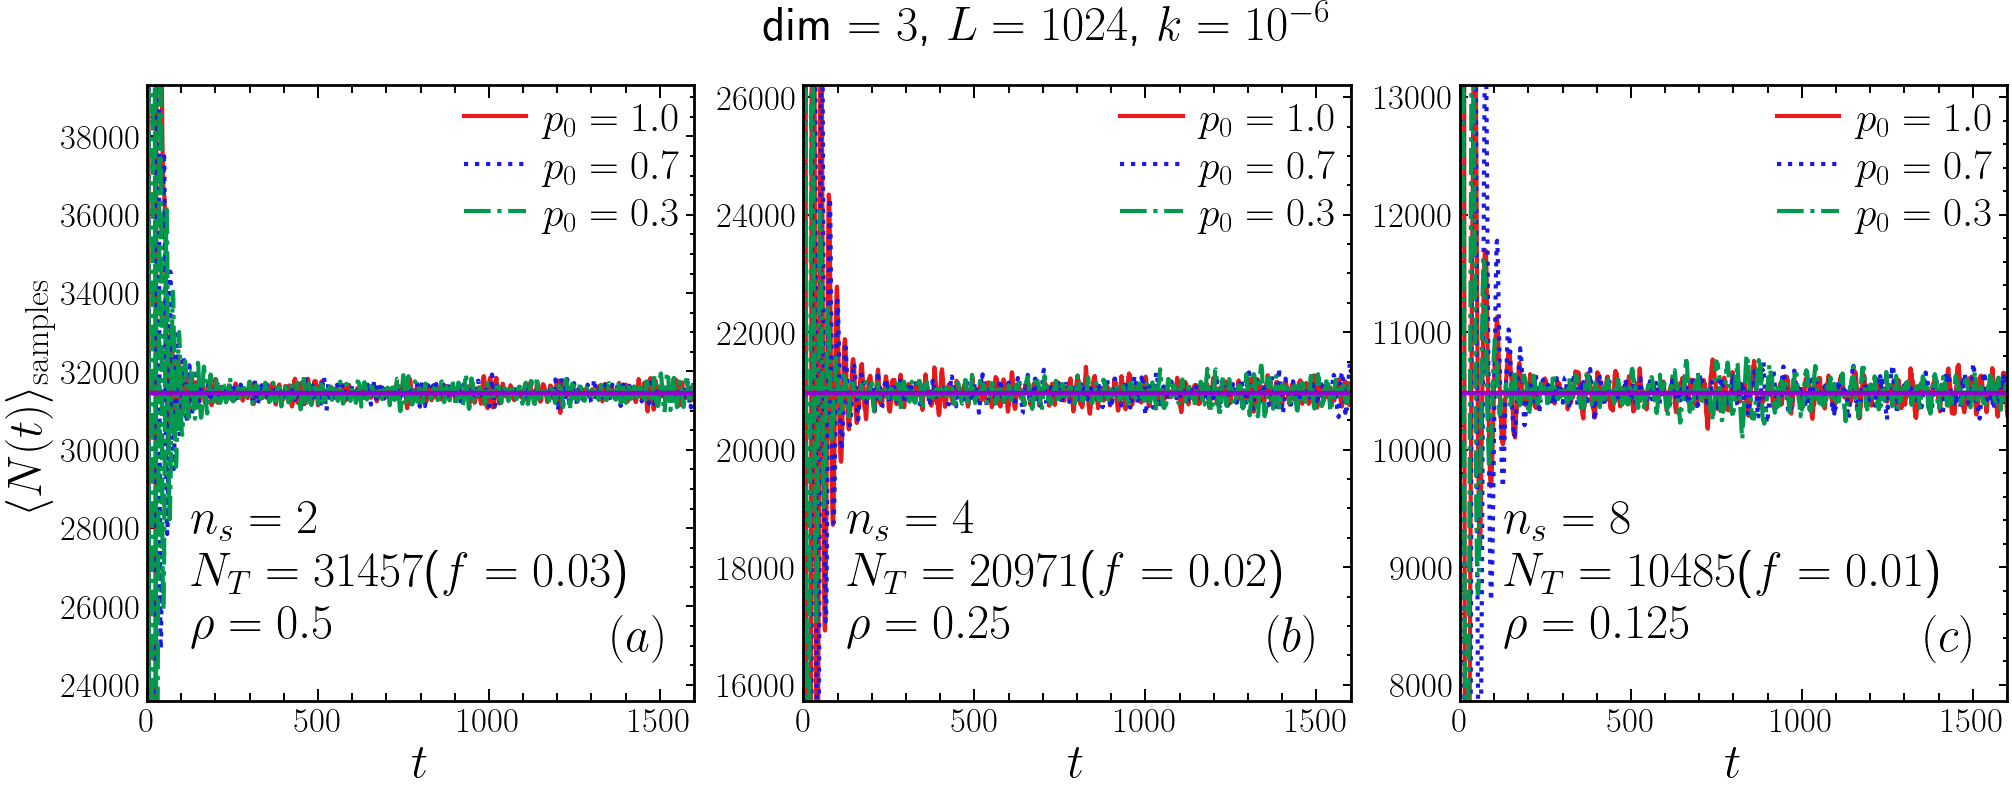

In [84]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================
L = 1024
dim = 3
#nc = 1
#rho = 1 / nc
k = 1.0e-06
#f0 = 0.04

p0_lst = [1.0, 0.7, 0.3]
order_raw = 1
lw = 3.0
fs_label =  35
fs_legend = 30
fs_labels_fig = 35
fs_ticks = 25
fs_title = 35

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]

# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
NT = 41943
# nc, NT, rho
#parms = [[2, int(0.03*L**2), 1/2],[4, int(0.01*L**2), 1/4], [8, int(0.01*L**2), 1/8]]
f0_lst = [0.03, 0.02, 0.01]
parms = [[2, int(f0_lst[0]*L**2), 1/2],[4, int(f0_lst[1]*L**2), 1/4], [8, int(f0_lst[2]*L**2), 1/8]]
pc = 0.24881182
ls = ['solid', 'dotted', 'dashdot']
base = 8
fig, ax = plt.subplots(1, 3, figsize=(3*base, base), sharex=True)

order_mean = 0
for idx_nc, par in enumerate(parms):
    print(par)
    nc = par[0]
    NT = par[1]
    rho = par[2]
    path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
    bundle_path = path_dir_pub + "properties_mean_bundle.json"
    bundle = load_properties_bundle(bundle_path)

    for idx, p0_val in enumerate(p0_lst):
        data = bundle[p0_val]["orders"][order_mean]
        time = data["time"]
        pt_mean = data["nt_mean"]

        ax[idx_nc].plot(time, pt_mean, lw=lw, ls=ls[idx], color=colors[idx], label=fr"$p_0 = {p0_val:.1f}$")

title = [r'$n_c = 2$', r'$n_c = 4$', r'$n_c = 8$']
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$']

for idx, a in enumerate(ax):
    ns = parms[idx][0]
    NT = parms[idx][1]
    rho = parms[idx][2]
    
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, labelleft=False, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, labelleft=False, length=3)
    a.set_ylim(NT*0.75,1.25*NT)
    a.set_xlim(0, 1600)
    a.axhline(y=NT, color="darkviolet", lw=1.05*lw)
    a.set_xlabel(r"$t$",fontsize=fs_label)
    a.legend(fontsize=fs_legend, handlelength=1.5)
    a.tick_params(axis='y', which='major', labelleft=True)
    a.text(0.85, 0.08, labels_fig[idx], transform=a.transAxes , fontsize=fs_labels_fig)
    a.text(0.08, 0.10,f"$n_s = {ns}$" +"\n" + f"$N_T = {NT}$($f = {f0_lst[idx]}$)" + "\n" + f"$\\rho = {rho}$", transform=a.transAxes , fontsize=fs_labels_fig)
    a.tick_params(axis='both', labelsize=fs_ticks)

ax[0].set_ylabel(r'$\langle N(t) \rangle_{\mathrm{samples}}$',fontsize=fs_label)
mantissa, exp = f"{k:.1e}".split("e")
fig.suptitle(f"dim $= {dim}$, $L = {L}$, $k=10^{{{int(exp)}}}$", fontsize=35)
plt.savefig(results_folder + f"/L_{L}_Nt_multiple_p0_ns.pdf")
plt.show()

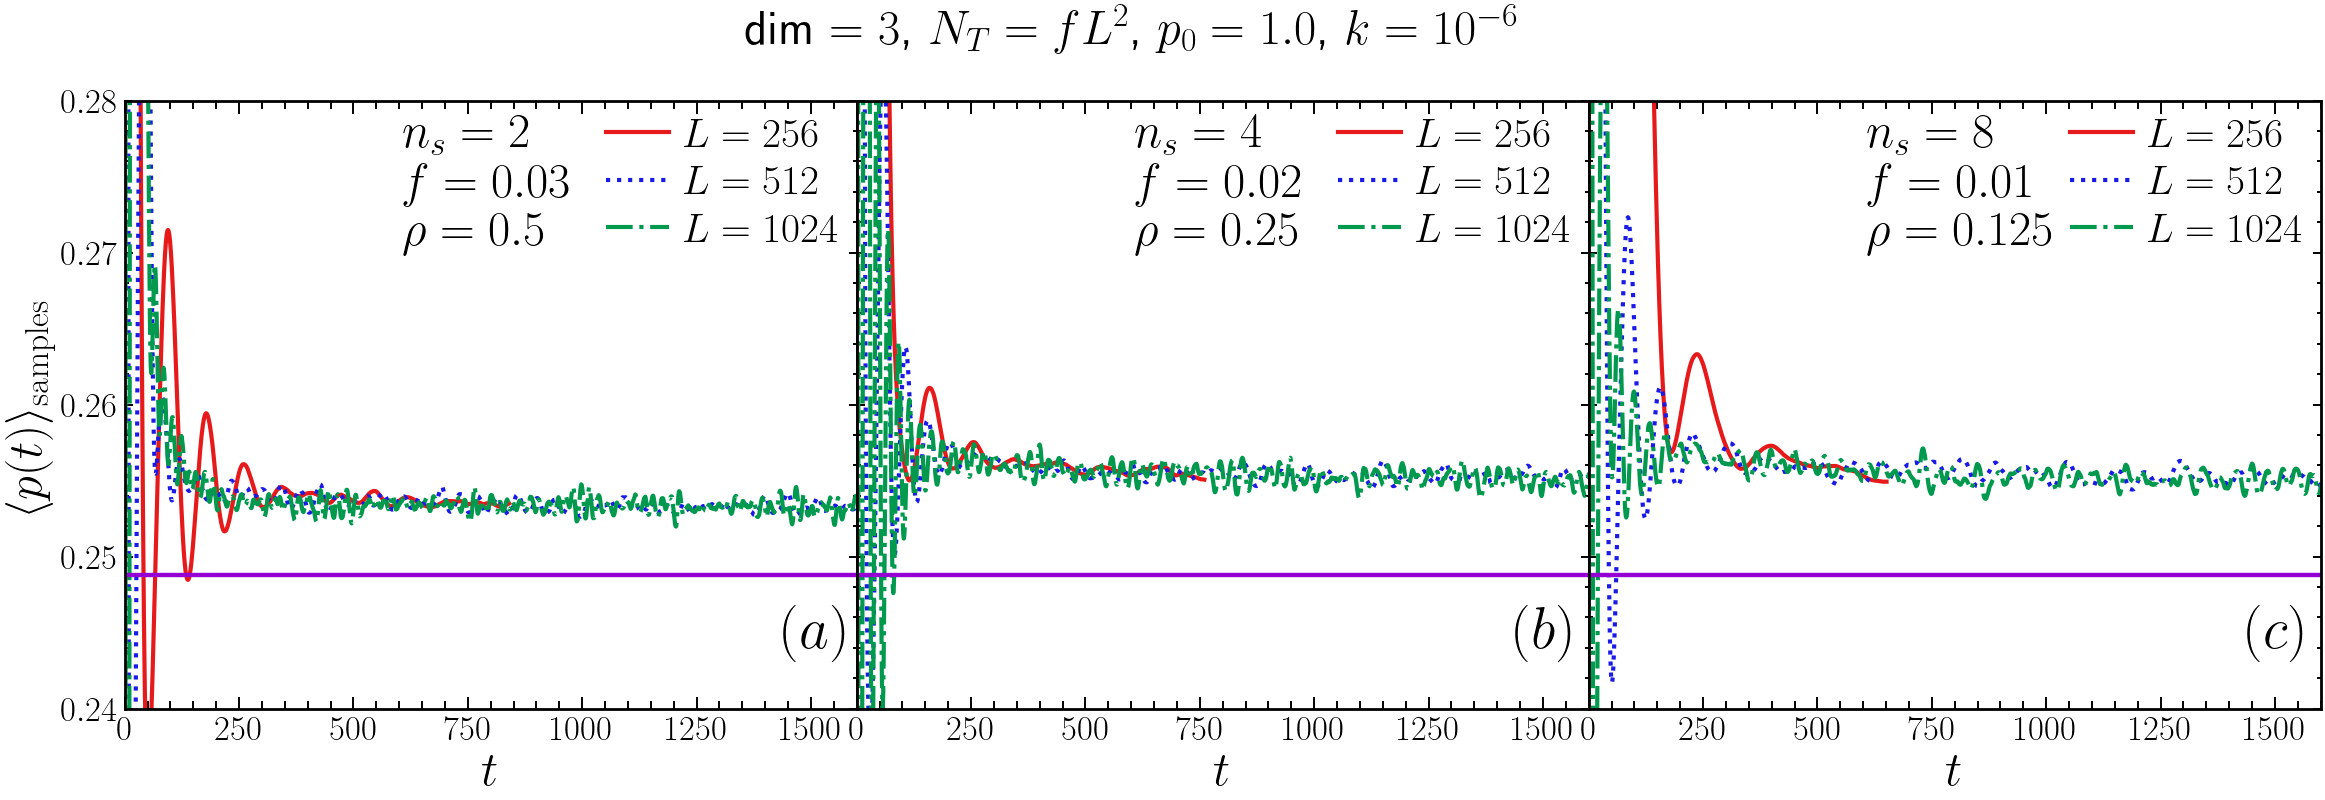

In [86]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================

dim = 3
#nc = 1
#rho = 1 / nc
k = 1.0e-06
#f0 = 0.04

order_raw = 1
lw = 3.0
fs_label =  35
fs_legend = 30
fs_labels_fig = 35
fs_ticks = 25
fs_title = 35

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]

# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
NT = 41943
# nc, NT, rho
#parms = [[2, int(0.03*L**2), 1/2],[4, int(0.01*L**2), 1/4], [8, int(0.01*L**2), 1/8]]
f0_lst = [0.03, 0.02, 0.01]
L_lst = [256, 512, 1024]
pc = 0.24881182
ls = ['solid', 'dotted', 'dashdot']
base = 8
fig, ax = plt.subplots(1, 3, figsize=(3*base, base), sharey=True, sharex=True,  gridspec_kw={"wspace": 0, "hspace": 0})
fig.subplots_adjust(left=0.08, right=0.995, bottom=0.12, top=0.88, wspace=0)
order_mean = 0
p0 = 1.0
nc_lst = [2, 4, 8]
for idx, nc in enumerate(nc_lst):
    for idx_L, L in enumerate(L_lst):
        NT = int(f0_lst[idx]*L**2)
        rho = 1/nc
        path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
        bundle_path = path_dir_pub + "properties_mean_bundle.json"
        bundle = load_properties_bundle(bundle_path)

        data = bundle[p0]["orders"][order_mean]
        time = data["time"]
        pt_mean = data["pt_mean"]

        ax[idx].plot(time, pt_mean, lw=lw, ls=ls[idx_L], color=colors[idx_L], label=fr"$L = {L}$")

title = [r'$n_c = 2$', r'$n_c = 4$', r'$n_c = 8$']
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$']

for idx, a in enumerate(ax):
    f0 = f0_lst[idx]
    rho = 1/nc_lst[idx]
    
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, length=3)

    a.set_ylim(0.24, 0.28)
    a.set_xlim(0, 1600)
    a.axhline(y=pc, color="darkviolet", lw=1.05*lw)

    a.set_xlabel(r"$t$", fontsize=fs_label)
    a.legend(fontsize=fs_legend, handlelength=1.5)
    a.text(0.9, 0.10, labels_fig[idx], transform=a.transAxes, fontsize=1.2*fs_labels_fig)
    a.text(0.38, 0.76,f"$n_s = {nc_lst[idx]}$" + "\n" + f"$f = {f0_lst[idx]}$" + "\n" + f"$\\rho = {rho}$",
           transform=a.transAxes, fontsize=fs_labels_fig)
    a.tick_params(axis='both', labelsize=fs_ticks)

    # só o primeiro painel mostra labels no eixo y
    if idx == 0:
        a.tick_params(axis='y', which='major', labelleft=True)
    else:
        a.tick_params(axis='y', which='both', labelleft=False)

ax[0].set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_label)
mantissa, exp = f"{k:.1e}".split("e")
fig.suptitle(f"dim $= {dim}$, $N_T = fL^2$, $p_0 = {p0}$, $k=10^{{{int(exp)}}}$", fontsize=35, y=1.00)
plt.savefig(results_folder + f"/multi_L_pt_multi_ns.pdf")
plt.show()

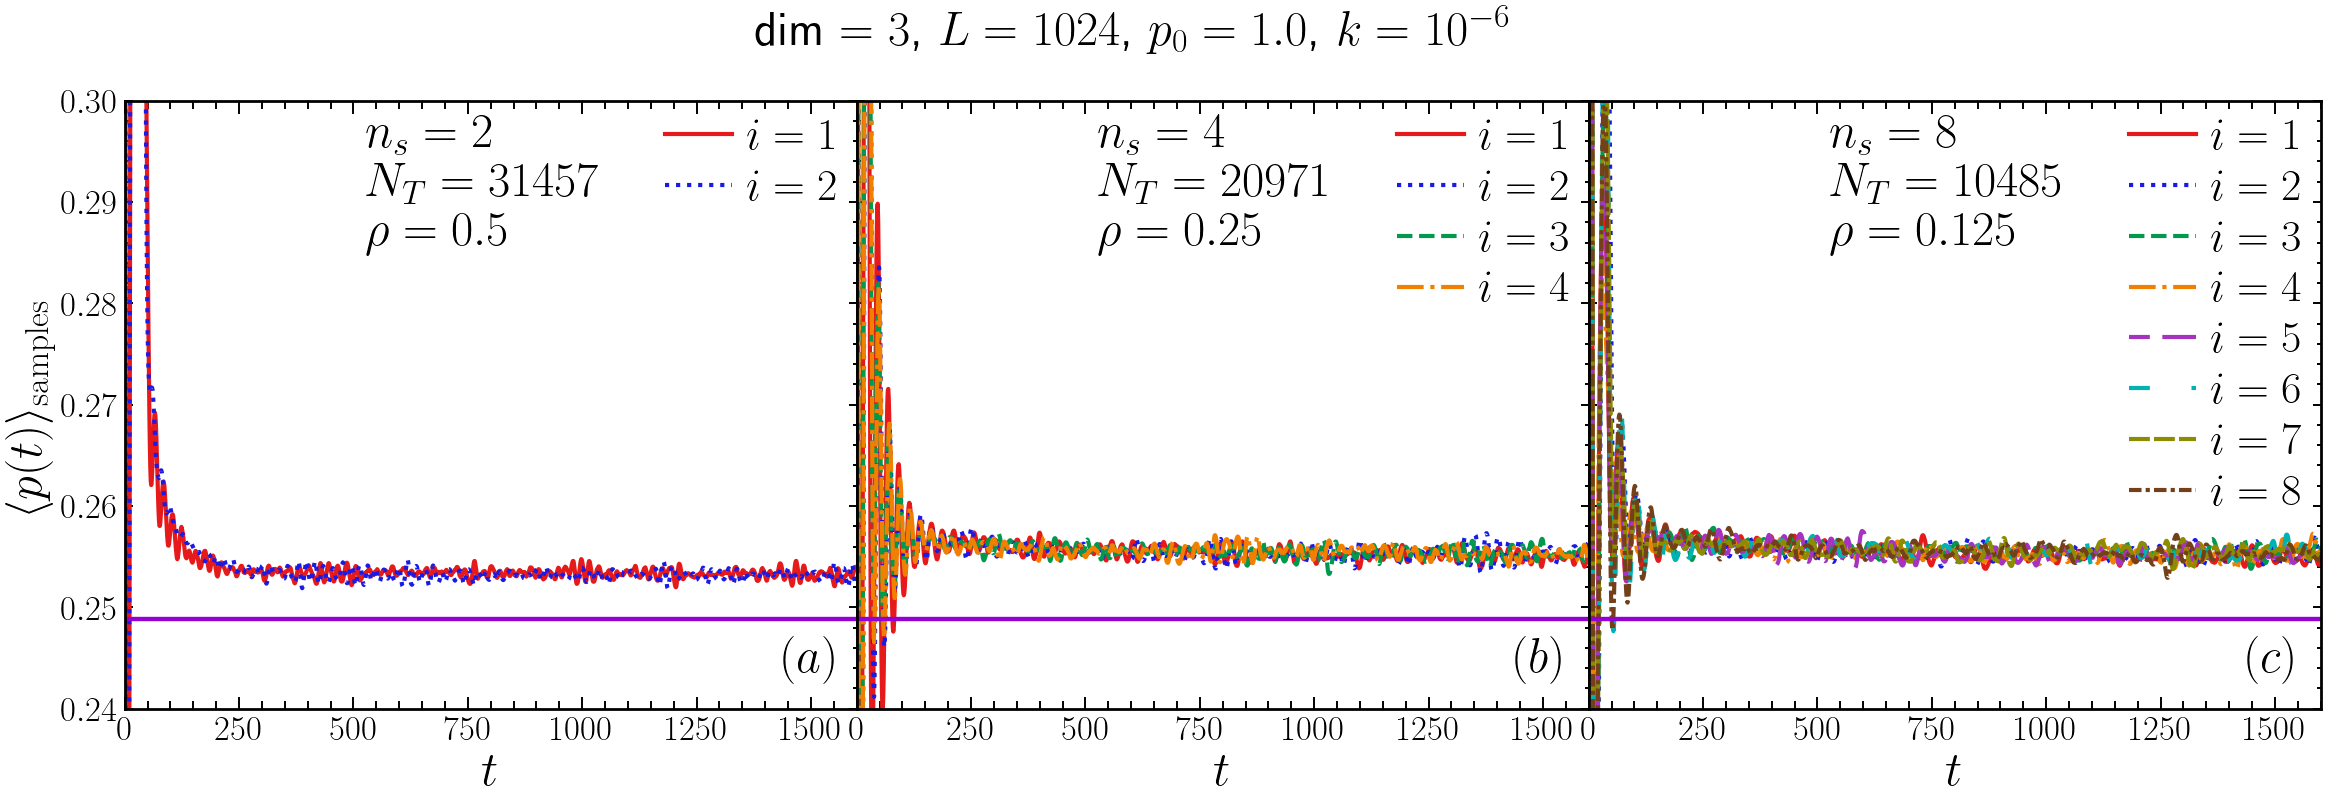

In [87]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================

dim = 3
#nc = 1
#rho = 1 / nc
k = 1.0e-06
#f0 = 0.04

order_raw = 1
lw = 3.0
fs_label =  35
fs_legend = 32
fs_labels_fig = 35
fs_ticks = 25
fs_title = 35

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]

# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
NT = 41943
# nc, NT, rho
#parms = [[2, int(0.03*L**2), 1/2],[4, int(0.01*L**2), 1/4], [8, int(0.01*L**2), 1/8]]
f0_lst = [0.03, 0.02, 0.01]
L = 1024
pc = 0.24881182
ls = ['solid', 'dotted', 'dashed','dashdot', (5,(10,3)), (0, (5,10)), (0, (5,1)), (0, (3,1,1,1))]
base = 8
fig, ax = plt.subplots(1, 3, figsize=(3*base, base), sharey=True, sharex=True,  gridspec_kw={"wspace": 0, "hspace": 0})
fig.subplots_adjust(left=0.08, right=0.995, bottom=0.12, top=0.88, wspace=0)
#order_mean = 0
p0 = 1.0
nc_lst = [2, 4, 8]
for idx, nc in enumerate(nc_lst):
    NT = int(f0_lst[idx]*L**2)
    rho = 1/nc
    path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
    bundle_path = path_dir_pub + "properties_mean_bundle.json"
    bundle = load_properties_bundle(bundle_path)

    for order, data in sorted(bundle[p0]["orders"].items()):
        time = data["time"]
        pt_mean = data["pt_mean"]
        ax[idx].plot(time, pt_mean, lw=lw, ls=ls[order], color=colors[order], label=fr"$i = {order+1}$")
#     time = data["time"]
#     pt_mean = data["pt_mean"]

#     ax[idx].plot(time, pt_mean, lw=lw, ls=ls[idx], color=colors[idx], label=fr"$L = {L}$")

title = [r'$n_c = 2$', r'$n_c = 4$', r'$n_c = 8$']
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$']

for idx, a in enumerate(ax):
    
    N_T = f0_lst[idx]*L**2
    rho = 1/nc_lst[idx]
    
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, length=3)

    a.set_ylim(0.24, 0.30)
    a.set_xlim(0, 1600)
    a.axhline(y=pc, color="darkviolet", lw=1.05*lw)

    a.set_xlabel(r"$t$", fontsize=fs_label)
    
    a.legend(fontsize=fs_legend, handlelength=1.5)
    a.text(0.9, 0.06, labels_fig[idx], transform=a.transAxes, fontsize=fs_labels_fig)
    a.text(0.33, 0.76,f"$n_s = {nc_lst[idx]}$" + '\n' + f"$N_T = {int(N_T)}$" + "\n" + f"$\\rho = {rho}$",
           transform=a.transAxes, fontsize=fs_labels_fig)
    a.tick_params(axis='both', labelsize=fs_ticks)

    # só o primeiro painel mostra labels no eixo y
    if idx == 0:
        a.tick_params(axis='y', which='major', labelleft=True)
    else:
        a.tick_params(axis='y', which='both', labelleft=False)

ax[0].set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_label)
mantissa, exp = f"{k:.1e}".split("e")
fig.suptitle(f"dim $= {dim}$, $L=1024$, $p_0 = {p0}$, $k=10^{{{int(exp)}}}$", fontsize=35, y=1.00)
plt.savefig(results_folder + f"/pt_multi_ns_orders.pdf")
plt.show()

[2, 31457, 0.5]
[4, 20971, 0.25]
[8, 10485, 0.125]


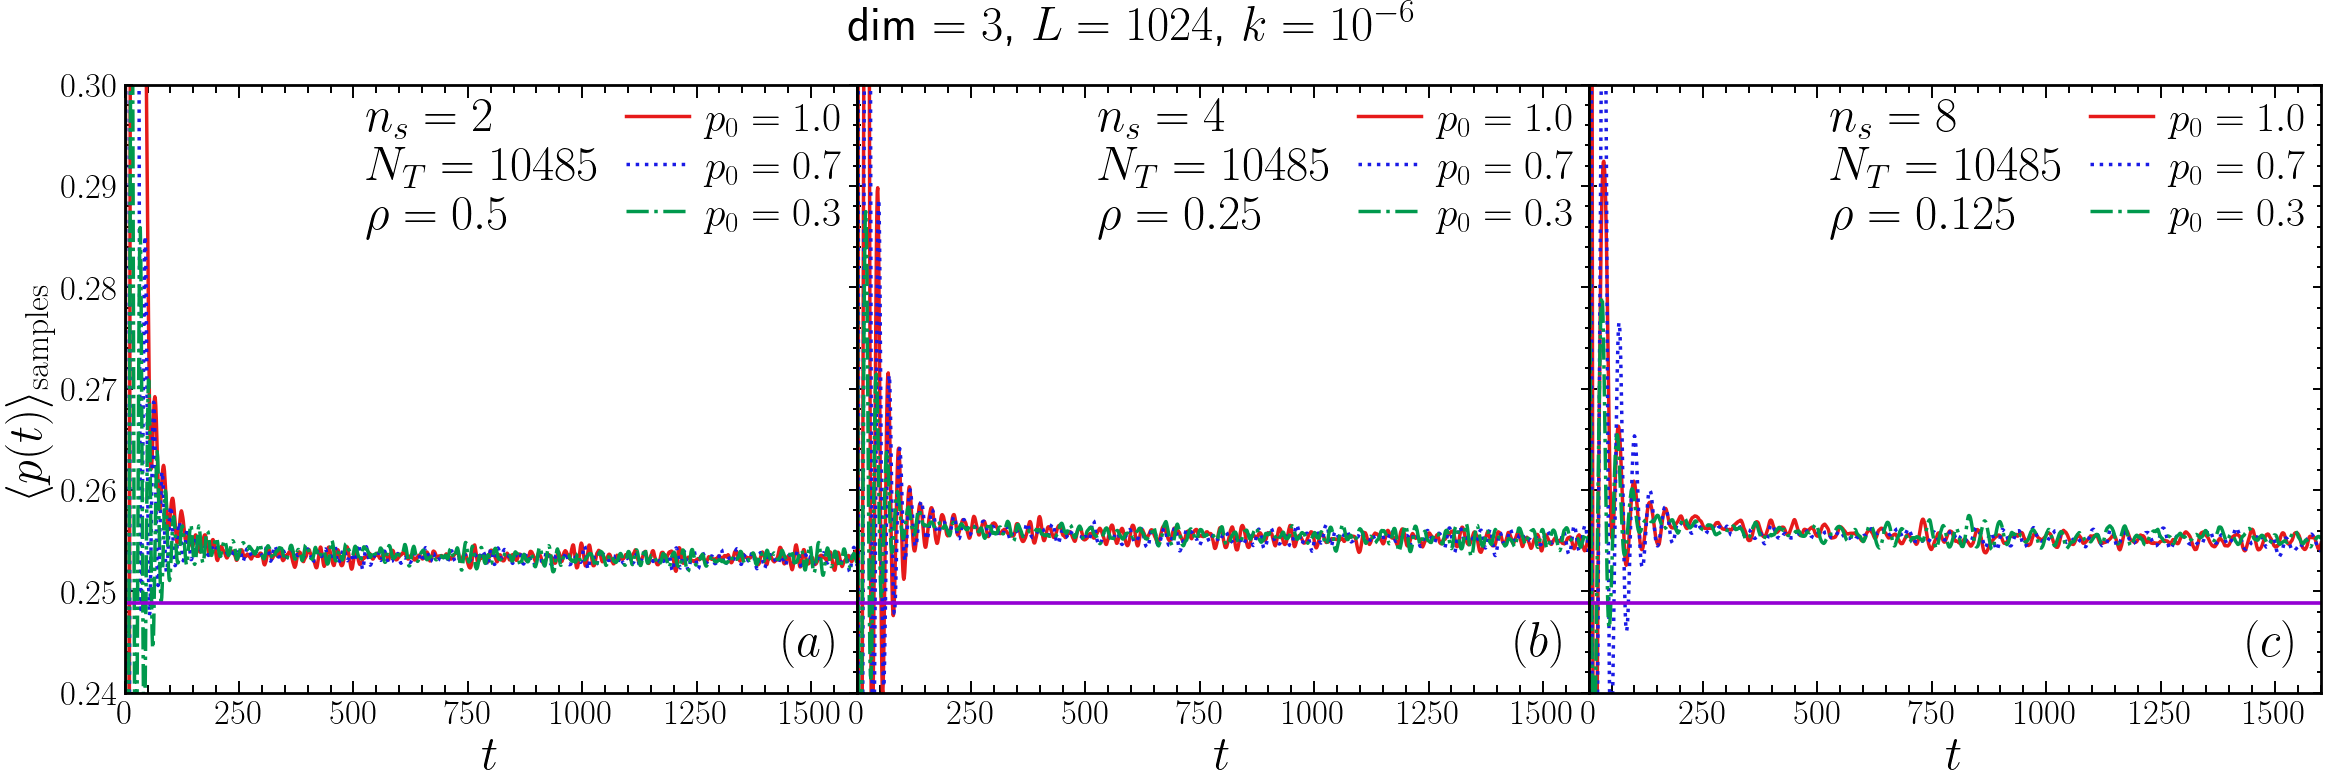

In [88]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================
L = 1024
dim = 3
#nc = 1
#rho = 1 / nc
k = 1.0e-06
#f0 = 0.04

p0_lst = [1.0, 0.7, 0.3]
order_raw = 1
lw = 2.5
fs_label =  35
fs_legend = 30
fs_labels_fig = 35
fs_ticks = 25
fs_title = 35

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]

# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
NT = 41943
# nc, NT, rho
#parms = [[2, int(0.03*L**2), 1/2],[4, int(0.01*L**2), 1/4], [8, int(0.01*L**2), 1/8]]
f0_lst = [0.03, 0.02, 0.01]
parms = [[2, int(f0_lst[0]*L**2), 1/2],[4, int(f0_lst[1]*L**2), 1/4], [8, int(f0_lst[2]*L**2), 1/8]]
pc = 0.24881182
ls = ['solid', 'dotted', 'dashdot']
base = 8
fig, ax = plt.subplots(1, 3, figsize=(3*base, base), sharey=True, sharex=True,  gridspec_kw={"wspace": 0, "hspace": 0})
fig.subplots_adjust(left=0.08, right=0.995, bottom=0.12, top=0.88, wspace=0)
order_mean = 0
for idx_nc, par in enumerate(parms):
    print(par)
    nc = par[0]
    NT = par[1]
    rho = par[2]
    path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
    bundle_path = path_dir_pub + "properties_mean_bundle.json"
    bundle = load_properties_bundle(bundle_path)

    for idx, p0_val in enumerate(p0_lst):
        data = bundle[p0_val]["orders"][order_mean]
        time = data["time"]
        pt_mean = data["pt_mean"]

        ax[idx_nc].plot(time, pt_mean, lw=lw, ls=ls[idx], color=colors[idx], label=fr"$p_0 = {p0_val:.1f}$")

title = [r'$n_c = 2$', r'$n_c = 4$', r'$n_c = 8$']
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$']
    
for idx, a in enumerate(ax):
    NT = parms[idx][1]
    rho = parms[idx][2]
    
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, length=3)

    a.set_ylim(0.24, 0.30)
    a.set_xlim(0, 1600)
    a.axhline(y=pc, color="darkviolet", lw=1.05*lw)

    a.set_xlabel(r"$t$", fontsize=fs_label)
    
    a.legend(fontsize=fs_legend, handlelength=1.5)
    a.text(0.9, 0.06, labels_fig[idx], transform=a.transAxes, fontsize=fs_labels_fig)
    a.text(0.33, 0.76,f"$n_s = {nc_lst[idx]}$" + '\n' + f"$N_T = {int(N_T)}$" + "\n" + f"$\\rho = {rho}$",
           transform=a.transAxes, fontsize=fs_labels_fig)
    a.tick_params(axis='both', labelsize=fs_ticks)

    # só o primeiro painel mostra labels no eixo y
    if idx == 0:
        a.tick_params(axis='y', which='major', labelleft=True)
    else:
        a.tick_params(axis='y', which='both', labelleft=False)

ax[0].set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$',fontsize=fs_label)
mantissa, exp = f"{k:.1e}".split("e")
fig.suptitle(f"dim $= {dim}$, $L = {L}$, $k=10^{{{int(exp)}}}$", fontsize=35)
plt.savefig(results_folder + f"/L_{L}_pt_multiple_p0_ns.pdf")
plt.show()

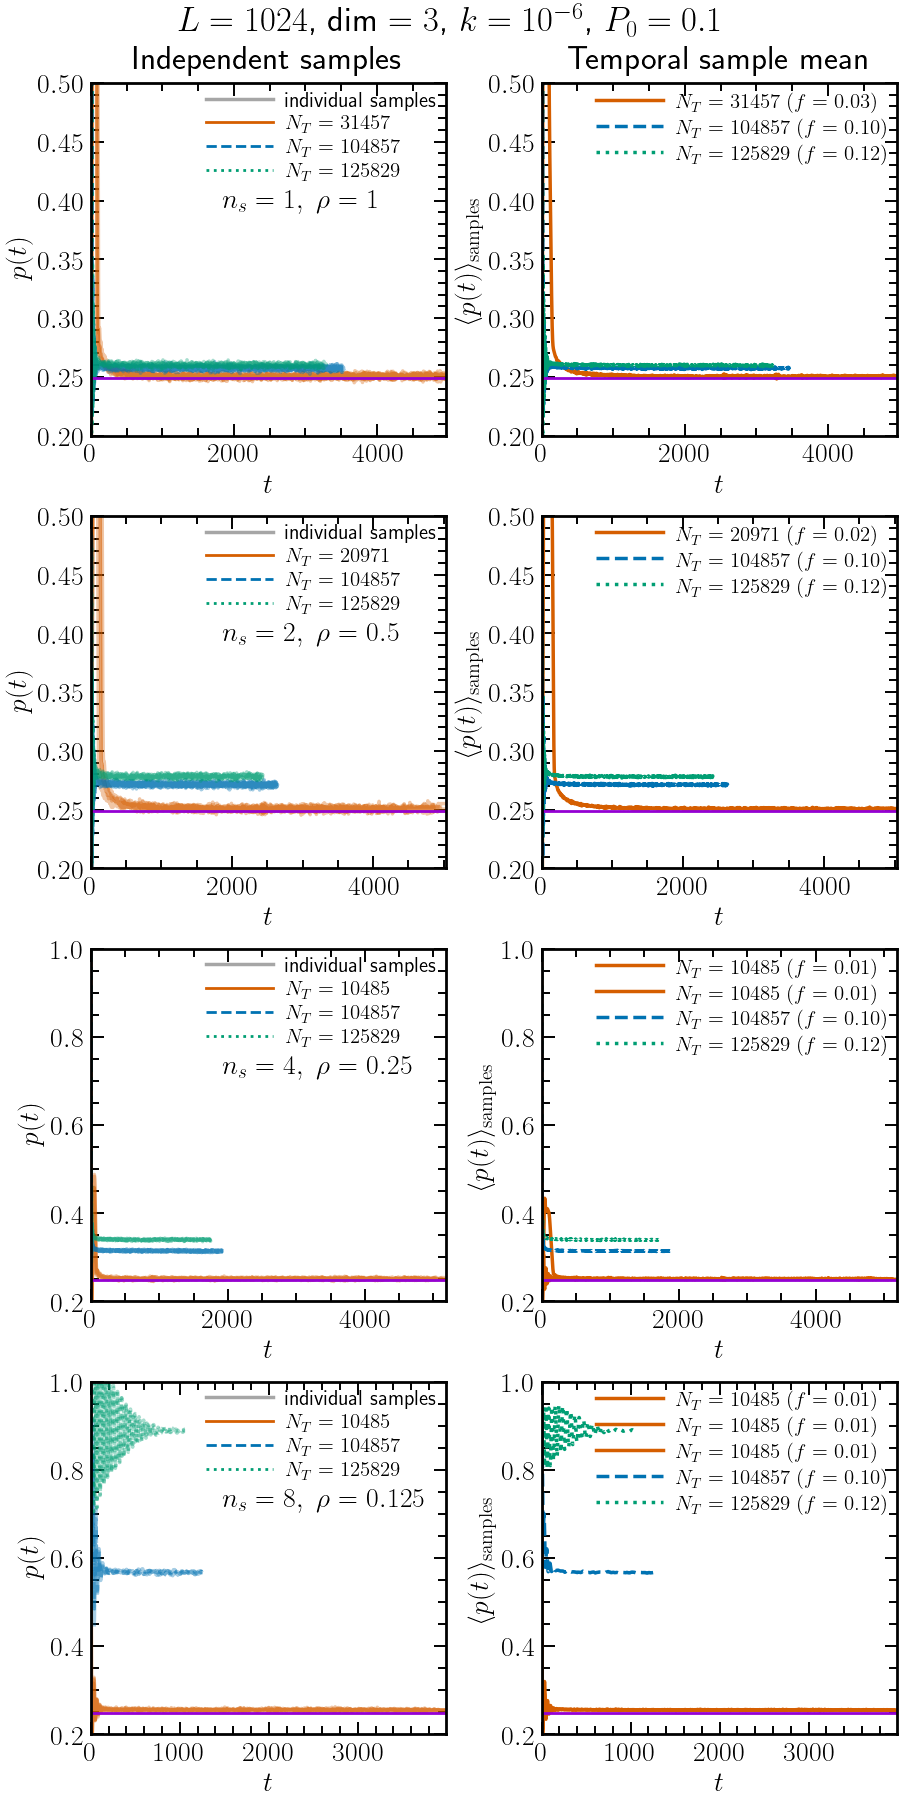

In [89]:
from matplotlib.lines import Line2D

L = 1024
dim = 3
k = 1.0e-06
p0 = 1.0
P0 = 0.1
N_samples = 4

order_raw = 1
order_mean = 0
pc = 0.24881182

# paleta consistente entre os dois paineis
colors_nt = ['#D55E00', '#0072B2', '#009E73']   # Okabe-Ito
ls = ['-', '--', ':']

lw_raw = 2.5
lw_mean = 2.5
alpha_raw = 0.35

# configuracoes de cada caso original, mantidas
configs = [
    {
        "nc": 1,
        "NT_lst": [31457, 104857, 125829],
        "ylim": (0.2, 0.5),
    },
    {
        "nc": 2,
        "NT_lst": [20971, 104857, 125829],
        "ylim": (0.2, 0.5),
    },
    {
        "nc": 4,
        "NT_lst": [10485, 104857, 125829],
        "ylim": (0.2, 1.0),
    },
    {
        "nc": 8,
        "NT_lst": [10485, 104857, 125829],
        "ylim": (0.2, 1.0),
    },
]
fs_legend = 15
base = 4.5
fig, axes = plt.subplots(
    4, 2,
    figsize=(2 * base, 4 * base),
    constrained_layout=True
)

for row, cfg in enumerate(configs):
    nc = cfg["nc"]
    rho = 1 / nc
    NT_lst = cfg["NT_lst"]
    ylim = cfg["ylim"]

    ax_raw = axes[row, 0]
    ax_mean = axes[row, 1]

    tmax = []

    for idx_N, NT in enumerate(NT_lst):
        path_dir_raw = (
            f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/"
            f"NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data/"
        )

        used_files = set()
        for idx in range(N_samples):
            fn = select_random_json(path_dir_raw, p0, P0, used_files)

            if fn is None:
                raise ValueError(
                    f"Não há arquivos suficientes para sortear sem repetição para nc={nc}, NT={NT}."
                )

            dicT = read_experiment_json(fn)
            pt = dicT['results'][f'order_percolation {order_raw}']['data']['pt']
            t = dicT['results'][f'order_percolation {order_raw}']['data']['time']

            ax_raw.plot(
                t, pt,
                ls=ls[idx_N],
                lw=lw_raw,
                alpha=alpha_raw,
                color=colors_nt[idx_N]
            )

        path_dir_pub = (
            f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/"
            f"NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
        )
        bundle_path = path_dir_pub + "properties_mean_bundle.json"
        bundle = load_properties_bundle(bundle_path)

        b = L**2
        f0 = NT / b

        for p0_val in sorted(bundle.keys()):
            data = bundle[p0_val]["orders"][order_mean]
            time = data["time"]
            pt_mean = data["pt_mean"]

            ax_mean.plot(
                time, pt_mean,
                color=colors_nt[idx_N],
                ls=ls[idx_N],
                lw=lw_mean,
                label=rf"$N_T={NT}\;(f={f0:.2f})$"
            )
            tmax.append(max(time))

    # titulos apenas na primeira linha
    if row == 0:
        ax_raw.set_title(r'Independent samples', pad=10)
        ax_mean.set_title(r'Temporal sample mean', pad=10)

    # labels
    ax_raw.set_ylabel(r'$p(t)$')
    ax_mean.set_ylabel(r'$\langle p(t)\rangle_{\mathrm{samples}}$')

    # identificacao da linha
    ax_raw.text(
        0.37, 0.70,
        rf"$n_s={nc},\ \rho={rho:g}$",
        #rf"$n_s={nc},\ \rho={rho:g}$" + "\n" + rf"{N_samples} independent samples per $N_T$",
        transform=ax_raw.transAxes,
        ha='left',
        va='top'
    )

    # limites e linha critica, preservados por linha
    xmax = max(tmax) if len(tmax) > 0 else 1.0
    for ax in (ax_raw, ax_mean):
        ax.axhline(y=pc, color="darkviolet", lw=2.0)
        ax.set_xlabel(r'$t$')
        ax.set_xlim(0, xmax)
        ax.set_ylim(*ylim)

    # legenda do painel esquerdo
    handles_left = [
        Line2D([0], [0], color='k', lw=lw_raw, alpha=alpha_raw, label='individual samples'),
        Line2D([0], [0], color=colors_nt[0], ls=ls[0], lw=2.0, label=rf'$N_T={NT_lst[0]}$'),
        Line2D([0], [0], color=colors_nt[1], ls=ls[1], lw=2.0, label=rf'$N_T={NT_lst[1]}$'),
        Line2D([0], [0], color=colors_nt[2], ls=ls[2], lw=2.0, label=rf'$N_T={NT_lst[2]}$'),
    ]
    ax_raw.legend(
        handles=handles_left,
        loc='upper right',
        frameon=False,
        handlelength=3.2,
        handletextpad=0.6,
        fontsize=fs_legend
    )

    # legenda do painel direito
    ax_mean.legend(
        loc='upper right',
        frameon=False,
        handlelength=3.2,
        handletextpad=0.6,
        fontsize=fs_legend
    )
fig.suptitle(f"$L = {L}$, dim $= 3$, $k=10^{{{-6}}}$, $P_0 = {P0}$", fontsize=25)
plt.savefig(results_folder + f"/L_{L}_all_ns.pdf")
plt.show()

# TIME SERIES - 1 COLOR

In [ ]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df.dropna()

In [ ]:
len(df)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# DIM = 3
# N_COLORS = 4
# NT = 3000
# K = 1.0e-6
# RHO = 1 / N_COLORS

# L_lst = [256, 512, 1024]

# colors_used = [
#     (0.9, 0.1, 0.1),
#     (0.1, 0.1, 0.9),
#     (0.1, 0.9, 0.1),
#     (1.0, 0.5, 0.0),
#     (0.8, 0.2, 0.8),
#     (0.2, 0.8, 0.8),
#     (1.0, 1.0, 0.0),
#     (0.6, 0.4, 0.2),
# ]

# pc = 0.24881182

# # =======================
# # PARÂMETROS DE ESTILO
# # =======================
# fs_ticks = 25            # fontsize dos ticks
# fs_labels = 30           # fontsize dos labels (x/y)
# fs_legend_global = 25    # fontsize da legenda global (fora)
# fs_legend_local = 23    # fontsize da legenda local (dentro)
# fs_text = 30             # fontsize dos textos (L e (a),(b)...)

# lw_dados = 2.5           # linewidth das curvas p(t)
# lw_pmean = 2.5           # linewidth das linhas mean_eq (tracejado)
# lw_pc = 3.0              # linewidth da linha p_c (horizontal)
# # =======================

# fig, axes = plt.subplots(
#     1, 3, figsize=(20, 6),
#     sharey=True,
#     sharex=True,
#     constrained_layout=True
# )

# axes = np.atleast_1d(axes)
# labels_alfa = ['$(a)$', '$(b)$', '$(c)$']

# for idx_ax, (ax, L) in enumerate(zip(axes, L_lst)):

#     orders, num_seeds = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)

#     if isinstance(orders, dict):
#         if "0" in orders:
#             orders = [orders[str(i)] for i in range(N_COLORS)]
#         else:
#             orders = [orders[i] for i in range(N_COLORS)]

#     series = []
#     for i in range(N_COLORS):
#         d = orders[i]["data"]
#         t = np.array(d["time"], dtype=float)
#         pt = np.array(d["pt_mean"], dtype=float)
#         pt_sem = np.array(d["pt_sem"], dtype=float)
#         series.append((t, pt, pt_sem))

#     t0_ind = []
#     for (t, pt, pt_sem) in series:
#         idx0_i = detect_equilibrium_start_with_errors(
#             t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0
#         )
#         t0_ind.append(float(t[idx0_i]))
#     t0_global = float(max(t0_ind))

#     mean_eq_list = []

#     for i, (t, pt, pt_sem) in enumerate(series):
#         idx0_g = idx_from_t0(t, t0_global)
#         mean_eq, sem_eq = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
#         mean_eq_list.append(mean_eq)

#         err = (abs(mean_eq - pc) / pc) * 100
        

#         ax.plot(t, pt, ls='-', color=colors_used[i], lw=lw_dados)
#         ax.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])
#         ax.axhline(mean_eq, linestyle="--", linewidth=lw_pmean, alpha=0.9, color=colors_used[i])

#     ax.axhline(y=pc, linestyle="-", color="k", linewidth=lw_pc, alpha=0.6)

#     ax.set_xlim(0, max(series[0][0]))
#     ax.set_ylim(0.24, 0.28)

#     # labels
#     ax.set_xlabel(r"$t$", fontsize=fs_labels)
#     if idx_ax == 0:
#         ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)
#     else:
#         ax.set_ylabel("")

#     # ticks (numéricos em todos)
#     ax.tick_params(axis='both', which='both',width=1.8, length=9, labelsize=fs_ticks)
#     ax.tick_params(axis='x', labelbottom=True)

#     # legenda local
#     local_handles = [
#         Line2D([0], [0], color=colors_used[i], lw=lw_pmean, linestyle="--",
#                label=rf"$\langle p^{i+1}(t) \rangle={mean_eq_list[i]:.8f}$")
#         for i in range(N_COLORS)
#     ]
#     ax.legend(
#         handles=local_handles,
#         loc="best",
#         frameon=False,
#         fontsize=fs_legend_local,
#         handlelength=2.6,
#         borderaxespad=0.6
#     )

#     # textos (a),(b),(c) e L
#     ax.text(0.95, 0.05, labels_alfa[idx_ax],
#             transform=ax.transAxes, ha='right', va='bottom',
#             fontsize=fs_text)

#     ax.text(0.29, 0.87, f"$L = {L}$",
#             transform=ax.transAxes, ha='right', va='bottom',
#             fontsize=fs_text)

# # legenda global
# handles_i = [
#     Line2D([0], [0], color=colors_used[i], lw=2, label=fr"$i={i+1}$")
#     for i in range(N_COLORS)
# ]
# handle_pc = Line2D([0], [0], color="k", lw=lw_pc, linestyle="-", alpha=0.6,
#                    label=rf"$p_c={pc:.8f}$")

# fig.legend(
#     handles=handles_i + [handle_pc],
#     loc="center left",
#     bbox_to_anchor=(1.01, 0.5),
#     frameon=False,
#     ncol=1,
#     fontsize=fs_legend_global
# )

# plt.savefig(results_folder_pt + "pc_versus_L.pdf")
# plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# DIM = 3
# NT = 3000
# K = 1.0e-6

# L_lst = [256, 512, 1024]

# # agora vamos plotar nc = 2, 4, 8 em CADA L
# NC_LIST = [2, 4, 8]
# LS_BY_NC = {2: "solid", 4: "dotted", 8: "dashed"}  # estilos por nc

# colors_used = [
#     (0.9, 0.1, 0.1),
#     (0.1, 0.1, 0.9),
#     (0.1, 0.9, 0.1),
#     (1.0, 0.5, 0.0),
#     (0.8, 0.2, 0.8),
#     (0.2, 0.8, 0.8),
#     (1.0, 1.0, 0.0),
#     (0.6, 0.4, 0.2),
# ]

# pc = 0.24881182
# rho = 0.125

# # =======================
# # PARÂMETROS DE ESTILO
# # =======================
# fs_ticks = 18            # fontsize dos ticks
# fs_labels = 22           # fontsize dos labels (x/y)
# fs_legend_global = 22    # fontsize da legenda global (fora)
# fs_legend_local = 22     # fontsize da legenda local (dentro)
# fs_text = 25             # fontsize dos textos (L e (a),(b)...)

# lw_dados = 1.6           # linewidth das curvas p(t)
# lw_pmean = 2.1           # linewidth das linhas da legenda interna (nc) e/ou referências
# lw_pc = 2.2              # linewidth da linha p_c (horizontal)
# # =======================

# fig, axes = plt.subplots(
#     1, 3, figsize=(20, 6),
#     sharey=True,
#     sharex=True,
#     constrained_layout=True
# )

# axes = np.atleast_1d(axes)
# labels_alfa = ['$(a)$', '$(b)$', '$(c)$']

# for idx_ax, (ax, L) in enumerate(zip(axes, L_lst)):

#     # acumula todas as series de TODOS os nc para definir um t_eq GLOBAL por subplot (por L)
#     all_series = []  # lista de dicts: {nc, i, t, pt, sem}
#     num_seeds_by_nc = {}

#     for nc in NC_LIST:
#         # rho = 1.0 / nc
#         orders, num_seeds = read_mean_json(nc, DIM, L, NT, K, rho)
#         num_seeds_by_nc[nc] = num_seeds

#         if isinstance(orders, dict):
#             if "0" in orders:
#                 orders = [orders[str(i)] for i in range(nc)]
#             else:
#                 orders = [orders[i] for i in range(nc)]

#         for i in range(nc):
#             d = orders[i]["data"]
#             t = np.array(d["time"], dtype=float)
#             pt = np.array(d["pt_mean"], dtype=float)
#             pt_sem = np.array(d["pt_sem"], dtype=float)
#             all_series.append({"nc": nc, "i": i, "t": t, "pt": pt, "sem": pt_sem})

#     print(f"\n=== L={L} ===")
#     for nc in NC_LIST:
#         print(f"N_samples (num_seeds) nc={nc} -> {num_seeds_by_nc[nc]}")

#     # t_eq: calcula t0 por série e pega o máximo (para usar em todas as curvas do subplot)
#     t0_ind = []
#     for s in all_series:
#         t, pt, sem = s["t"], s["pt"], s["sem"]
#         idx0_i = detect_equilibrium_start_with_errors(
#             t, pt, sem, w=40, consec=6, z=2.0, chi2r_max=2.0
#         )
#         t0_ind.append(float(t[idx0_i]))
#     t0_global = float(max(t0_ind))

#     print(f"t0 GLOBAL (usado para TODAS no subplot L={L}): {t0_global:.2f}")

#     # plot: cor = i, linestyle = nc
#     for s in all_series:
#         nc, i = s["nc"], s["i"]
#         t, pt, sem = s["t"], s["pt"], s["sem"]
#         ls = LS_BY_NC[nc]
#         color = colors_used[i]  # i=0..(nc-1)

#         ax.plot(t, pt, ls=ls, color=color, lw=lw_dados)
#         ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=color)

#     # linhas de referência
#     # ax.axvline(t0_global, linestyle="--", linewidth=1.5, color="k", alpha=0.7)
#     ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

#     # limites
#     ax.set_xlim(0, max(all_series[0]["t"]))
#     ax.set_ylim(0.24, 0.28)

#     # --------- MESMAS MUDANÇAS DO OUTRO CÓDIGO ---------

#     # xlabel em TODOS os plots
#     ax.set_xlabel(r"$t$", fontsize=fs_labels)

#     # ylabel apenas no primeiro subplot (à esquerda)
#     if idx_ax == 0:
#         ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)
#     else:
#         ax.set_ylabel("")

#     # ticks numéricos em TODOS + fontsize configurável
#     ax.tick_params(axis='both', which='both', labelsize=fs_ticks)
#     ax.tick_params(axis='x', labelbottom=True)

#     # ---------------------------------------------------

#     # legenda interna: SOMENTE nc (estilos)
#     inner_handles = [
#         Line2D([0], [0], color="k", lw=lw_pmean, linestyle=LS_BY_NC[nc], label=fr"$n_c={nc}$")
#         for nc in NC_LIST
#     ]
#     ax.legend(
#         handles=inner_handles,
#         loc="best",
#         frameon=False,
#         fontsize=fs_legend_local,
#         handlelength=2.6,
#         borderaxespad=0.6
#     )

#     ax.text(0.95, 0.05, labels_alfa[idx_ax],
#             transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

#     ax.text(0.33, 0.83, f"$L = {L}$",
#             transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

# # legenda global única (fora): SOMENTE cores (i), até i=8 (pois nc_max=8)
# handles_i = [
#     Line2D([0], [0], color=colors_used[i], lw=2, label=fr"$i={i+1}$")
#     for i in range(8)
# ]
# handle_pc = Line2D(
#     [0], [0],
#     color="darkviolet",
#     lw=lw_pc,
#     linestyle="-",
#     label=rf"$p_c = {pc:.8f}$"
# )

# fig.legend(
#     handles=handles_i + [handle_pc],
#     loc="center left",
#     bbox_to_anchor=(1.01, 0.5),
#     frameon=False,
#     ncol=1,
#     fontsize=fs_legend_global
# )

# plt.savefig(results_folder_pt + "pc_versus_L_all_nc.pdf")
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ================================
# PARÂMETROS GERAIS
# ================================
DIM = 3
NT = 3000
K = 1.0e-6

L_lst = [256, 512, 1024]

colors_used = [
    (0.84, 0.15, 0.16),  # vermelho forte
    (0.12, 0.47, 0.71),  # azul profundo
    (0.17, 0.63, 0.17),  # verde médio escuro
    (0.85, 0.37, 0.01),  # laranja queimado
    (0.58, 0.40, 0.74),  # roxo
    (0.55, 0.34, 0.29),  # marrom
    (0.09, 0.75, 0.81),  # ciano forte (escuro o suficiente)
    (0.50, 0.50, 0.50),  # cinza médio (ótimo para contraste sem brigar)
]

pc = 0.24881182

# =======================
# ESTILO (GLOBAL)
# =======================
fs_ticks = 30
fs_labels = 35
fs_legend_global = 34

# (5) separado por linha
fs_legend_local_top = 24
fs_legend_local_bottom = 30

fs_text = 35

lw_dados = 3.5
lw_pmean = 3.5
lw_pc = 3.5

tick_w = 1.8
tick_len = 9

# ================================
# CONFIGS FIGURA 1 (TOPO)
# ================================
N_COLORS = 4
RHO = 1 / N_COLORS

# ================================
# CONFIGS FIGURA 2 (BAIXO)
# ================================
NC_LIST = [2, 4, 8]
LS_BY_NC = {2: "solid", 4: "dotted", 8: "dashed"}
rho_bottom = 0.125

# ==========================================================
# (3) PRE-PASS: encontrar t_max GLOBAL para compartilhar x
# ==========================================================
t_max_global = 0.0

# topo
for L in L_lst:
    orders, _ = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
    if isinstance(orders, dict):
        if "0" in orders:
            orders = [orders[str(i)] for i in range(N_COLORS)]
        else:
            orders = [orders[i] for i in range(N_COLORS)]
    for i in range(N_COLORS):
        t = np.array(orders[i]["data"]["time"], dtype=float)
        if t.size > 0:
            t_max_global = max(t_max_global, float(np.max(t)))

# baixo
for L in L_lst:
    for nc in NC_LIST:
        orders, _ = read_mean_json(nc, DIM, L, NT, K, rho_bottom)
        if isinstance(orders, dict):
            if "0" in orders:
                orders = [orders[str(i)] for i in range(nc)]
            else:
                orders = [orders[i] for i in range(nc)]
        for i in range(nc):
            t = np.array(orders[i]["data"]["time"], dtype=float)
            if t.size > 0:
                t_max_global = max(t_max_global, float(np.max(t)))

# ================================
# FIGURA 2x3 (x compartilhado)
# ================================
fig, axes = plt.subplots(
    2, 3, figsize=(29, 12),
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.08,
    right=0.78,   # mantém espaço p/ legenda global
    bottom=0.08,
    top=0.97,
    wspace=0.05,  # espaço horizontal (diminuir ↓)
    hspace=0.08   # espaço vertical (diminuir ↓)
)

# (4) labels (a) ... (f)
panel_labels = ['$(a)$', '$(b)$', '$(c)$', '$(d)$', '$(e)$', '$(f)$']

# ============================================================
# ======================= LINHA 1 (FIGURA 1) ==================
# ============================================================
for idx_col, L in enumerate(L_lst):
    ax = axes[0, idx_col]

    orders, _ = read_mean_json(N_COLORS, DIM, L, NT, K, RHO)
    if isinstance(orders, dict):
        if "0" in orders:
            orders = [orders[str(i)] for i in range(N_COLORS)]
        else:
            orders = [orders[i] for i in range(N_COLORS)]

    series = []
    for i in range(N_COLORS):
        d = orders[i]["data"]
        t = np.array(d["time"], dtype=float)
        pt = np.array(d["pt_mean"], dtype=float)
        pt_sem = np.array(d["pt_sem"], dtype=float)
        series.append((t, pt, pt_sem))

    # t_eq global por subplot
    t0_ind = []
    for (t, pt, pt_sem) in series:
        idx0_i = detect_equilibrium_start_with_errors(
            t, pt, pt_sem, w=40, consec=6, z=2.0, chi2r_max=2.0
        )
        t0_ind.append(float(t[idx0_i]))
    t0_global = float(max(t0_ind))

    mean_eq_list = []
    for i, (t, pt, pt_sem) in enumerate(series):
        idx0_g = idx_from_t0(t, t0_global)
        mean_eq, _ = weighted_mean_and_sem(pt[idx0_g:], pt_sem[idx0_g:])
        mean_eq_list.append(mean_eq)

        ax.plot(t, pt, ls='-', color=colors_used[i], lw=lw_dados)
        ax.fill_between(t, pt - pt_sem, pt + pt_sem, alpha=0.20, color=colors_used[i])
        ax.axhline(mean_eq, linestyle="--", linewidth=lw_pmean, alpha=0.9, color=colors_used[i])

    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

    # (3) x compartilhado com t_max_global
    ax.set_xlim(0, t_max_global)
    ax.set_ylim(0.24, 0.28)

    #ax.set_xlabel(r"$t$", fontsize=fs_labels)
    if idx_col == 0:
        ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)

    ax.tick_params(axis='both', which='both', width=tick_w, length=tick_len, labelsize=fs_ticks)

    # (2) legenda local do topo (como na figura 1 separada)
    local_handles = [
        Line2D([0], [0], color=colors_used[i], lw=lw_pmean, linestyle="--",
               label=rf"$\langle p^{i+1}(t) \rangle={mean_eq_list[i]:.4f}$")
        for i in range(N_COLORS)
    ]
    ax.legend(
        handles=local_handles,
        loc="best",
        frameon=False,
        fontsize=fs_legend_local_top,
        handlelength=2.6,
        borderaxespad=0.6
    )

    # (4) rótulos (a)-(f) e texto L
    ax.text(0.95, 0.05, panel_labels[idx_col],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)
    ax.text(0.31, 0.87, f"$L = {L}$",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

# ============================================================
# ======================= LINHA 2 (FIGURA 2) ==================
# ============================================================
for idx_col, L in enumerate(L_lst):
    ax = axes[1, idx_col]

    all_series = []  # (nc, i, t, pt, sem)
    for nc in NC_LIST:
        orders, _ = read_mean_json(nc, DIM, L, NT, K, rho_bottom)
        if isinstance(orders, dict):
            if "0" in orders:
                orders = [orders[str(i)] for i in range(nc)]
            else:
                orders = [orders[i] for i in range(nc)]

        for i in range(nc):
            d = orders[i]["data"]
            t = np.array(d["time"], dtype=float)
            pt = np.array(d["pt_mean"], dtype=float)
            pt_sem = np.array(d["pt_sem"], dtype=float)
            all_series.append((nc, i, t, pt, pt_sem))

    # plot: cor=i, linestyle=nc
    for (nc, i, t, pt, sem) in all_series:
        ax.plot(t, pt, ls=LS_BY_NC[nc], color=colors_used[i], lw=lw_dados)
        ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=colors_used[i])

    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

    # (3) x compartilhado com t_max_global
    ax.set_xlim(0, t_max_global)
    ax.set_ylim(0.24, 0.28)

    ax.set_xlabel(r"$t$", fontsize=fs_labels)
    if idx_col == 0:
        ax.set_ylabel(r"$p(t)$", fontsize=fs_labels)

    ax.tick_params(axis='both', which='both', width=tick_w, length=tick_len, labelsize=fs_ticks)

    # (2) legenda local do bottom (como na figura 2 separada): SOMENTE nc (estilos)
    inner_handles = [
        Line2D([0], [0], color="k", lw=lw_pmean, linestyle=LS_BY_NC[nc], label=fr"$n_s={nc}$")
        for nc in NC_LIST
    ]
    ax.legend(
        handles=inner_handles,
        loc="best",
        frameon=False,
        fontsize=fs_legend_local_bottom,
        handlelength=2.6,
        borderaxespad=0.6
    )

    # (4) rótulos (d)-(f) e texto L
    ax.text(0.95, 0.05, panel_labels[3 + idx_col],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)
    ax.text(0.31, 0.87, f"$L = {L}$",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=fs_text)

# ============================================================
# (1) LEGENDA GLOBAL (arrumada)
#    -> coloca fora, à direita, sem sobrepor eixos
# ============================================================
handles_i = [
    Line2D([0], [0], color=colors_used[i], lw=3.5, label=fr"$i={i+1}$")
    for i in range(8)
]
# handle_pc = Line2D([0], [0], color="darkviolet", lw=lw_pc, linestyle="-",
#                    label=rf"$p_c = {pc:.8f}$")

# dá espaço à direita para a legenda global
fig.subplots_adjust(right=0.78)

fig.legend(
    #handles=handles_i + [handle_pc],
    handles=handles_i,
    loc="center left",
    bbox_to_anchor=(0.80, 0.5),
    frameon=False,
    ncol=1,
    fontsize=fs_legend_global,
    handlelength=3.5,   # aumenta comprimento
    handleheight=1.5,
    borderpad=0.8
)

plt.savefig(results_folder_pt + "figura_unificada.pdf")
plt.show()


# $\rho$ ANALYSIS

## $P_c$ for multiples L

In [ ]:
nc= 4
orders = [i for i in range(1,nc+1)]
L_lst = [1024]
ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

colors = [
    (0.84, 0.15, 0.16),  # vermelho forte
    (0.12, 0.47, 0.71),  # azul profundo
    (0.17, 0.63, 0.17),  # verde médio escuro
    (0.85, 0.37, 0.01),  # laranja queimado
    (0.58, 0.40, 0.74),  # roxo
    (0.55, 0.34, 0.29),  # marrom
    (0.09, 0.75, 0.81),  # ciano forte (escuro o suficiente)
    (0.50, 0.50, 0.50),  # cinza médio (ótimo para contraste sem brigar)
]

fig, ax = plt.subplots(figsize=(13, 8),
    sharex=True,
    sharey=True
)
pc = 0.24881182
fs_ticks = 25
fs_labels = 30
fs_legend_global = 29
fs_legend_local = 29
thickness= 2.0
# (5) separado por linha
fs_legend_local_top = 24
fs_legend_local_bottom = 30
thickness_axes = 2.0
fs_text = 35

lw_dados = 2.0
lw_pmean = 3.3
lw_pc = 3.5

tick_w = 1.8
tick_len = 9

# =========================
# PLOT DOS DADOS
# =========================
for idx_L, L in enumerate(L_lst):
    for idx_ord, ord in enumerate(orders):
        df_sub = df[(df['L']==L) & (df['dim']==3) & (df['nc']==nc)]
        df_sub_ord = df_sub[df_sub['order']==ord]

        ax.plot(
            df_sub_ord['rho'],
            df_sub_ord['p_mean'],
            linestyle=ls[idx_ord],
            color=colors[idx_ord],
            lw=lw_dados,
            label=f"$i = {ord}$"
        )

# linha pc
ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

# =========================
# FORMATAÇÃO
# =========================
ax.set_xlim([0, 1/nc])
ax.set_xlabel(r"$\rho$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.tick_params(axis='both', which='major',
               labelsize=fs_ticks, length=9, width=thickness, pad=10)

ax.legend(fontsize=21)
ax.set_ylim([0.2485, 0.25])
for spine in ax.spines.values():
    spine.set_linewidth(thickness_axes)

plt.tight_layout()
#plt.savefig(results_folder + "/density_pc.pdf")
plt.show()

## $P_c$ for L = 512

In [ ]:
def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional

L = 512
NC_LIST = [2, 4, 8]
P0 = 0.1
p0 = 1.0
k=1.0e-06
DIM = 3
NT=3000
ylims = [(0.2, 1.1), (0.2, 0.37), (0.2, 0.37)]
pc_reff =  0.24881182
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True,sharex='col')  # 3x3 grid
thickness_axes = 1.4
WINDOW = 5
NC_list = [2, 4, 8]
ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]
colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.8, 0.2, 0.8),  # 6 - purple
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
labels_fig = ["$(a)$", "$(b)$", "$(c)$"]

legend_lines = {}
# Laço para cada linha de L
for i, nc in enumerate(NC_list):
        ax = axes[i]
        orders = [i for i in range(1, nc+1)]

        for idx_ord, order in enumerate(orders):
            df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"] == P0) & (df["p0"] == p0)].copy()
            if df_f.empty:
                continue
            df_f = df_f.sort_values("rho")

            x = df_f["rho"].to_numpy()
            y = df_f["p_mean"].to_numpy()

            y_ma = (
                pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW // 2)).mean().to_numpy()
            )
            y_std = (
                pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW // 2)).std().to_numpy()
            )
            y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y) + 1)))

            ax.plot(x, y, alpha=0.35)
            lines, = ax.plot(x, y_ma, linewidth=2, ls=ls[idx_ord], color=colors[idx_ord],label=f"$i = {order}$")
            ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
            rho_max = max(x)
            rho_min = min(x)
            
            if order not in legend_lines:
                legend_lines[order] = lines
        
        
        ax.set_title(rf"$L = {L}$, $n_c = {nc}$")
        
        ax.set_xlim([0, 1 / nc])
        
        ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)

        ax.axhline(y=pc_reff, color='k', linestyle='--', linewidth=1.6, label=f'$p_c = {pc_reff}$')
        
        aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f')
        
        ax.tick_params(axis='y', which='both', labelleft=False)
        
        if( i == 0):
            ax.tick_params(axis='y', which='both', labelleft=True, pad=5)
            ax.set_ylabel(r"$P_c^{\infty}$", fontsize=30)
    
        ax.tick_params(axis='x', which='both', labelbottom=True,pad=10)
        ax.set_xlabel(r"$\rho$", fontsize=30)

        ax.text(0.95, 0.85, labels_fig[i],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

fig.subplots_adjust(right=0.82)


handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# Adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')  # Linha para p_c
handles.append(pc_handle)
labels.append(fr'$p_c={pc_reff}$')  # Adicionando rótulo corretamente

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.83, 0.5),
           frameon=False)

fig.suptitle(fr"dim $= {DIM}$, $k = {k:.1e}$, $N_t = {NT}$, $p_0 = {p0}$", 
             fontsize=25, 
             fontweight='bold',
             y=1.01 )  # Adds a title to the entire figure

#plt.savefig(results_folder + "/rho/rho_PC_L_512_nc.pdf")
plt.show()

## $\rho_{min}$ versus L

# Figure tese

In [ ]:
tese_folder = "../results/tese/time_moments"
create_folder(tese_folder)

def aplicar_ticks(ax,
                  n_yticks=6,
                  yfmt='%.3f',
                  x_major_step=50,
                  x_minor_step=10,
                  n_yminor=4):
    """
    x_major_step: passo entre major ticks de x (inteiro)
    x_minor_step: passo entre minor ticks de x (inteiro)
    n_yticks    : nº de major ticks em y (como antes)
    n_yminor    : nº de subdivisões em y (como antes)
    """

    # ---------- EIXO X: SOMENTE INTEIROS ----------
    # major em múltiplos inteiros de x_major_step
    if x_major_step is not None:
        ax.xaxis.set_major_locator(MultipleLocator(base=x_major_step))

    # minor também em inteiros (múltiplos de x_minor_step)
    if x_minor_step is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(base=x_minor_step))

    # ---------- EIXO Y: igual ao que você já usava ----------
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    if n_yminor is not None and n_yminor > 0:
        ax.yaxis.set_minor_locator(AutoMinorLocator(n_yminor + 1))

    # estilo geral dos ticks
    ax.tick_params(axis='both', which='major',
                   direction='in', top=True, right=True, length=13,labelsize=22)
    ax.tick_params(axis='both', which='minor',
                   direction='in', top=True, right=True, length=7,labelsize=22)

    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))

L = 256
nc = 4
P0 = 0.1
p0 = 1.0
k = 1.0e-06
DIM = 3
NT = 3000
rho = 1/nc
pc_reff = 0.24881182

path_json = f"../network/{DIM}D_L{L}_nc{nc}_rho{rho}_k{k:.1e}_Nt{NT}/P0_0.10_p0_1.00_seed_1.json"
data = read_orders_one_file_fix(path_json)['results']

# diminui o espaçamento vertical com gridspec_kw OU ajustando depois
fig, axes = plt.subplots(
    2, 1,
    figsize=(15, 11),
    sharey=False,
    sharex='col',
    gridspec_kw={'hspace': 0.05}  # <-- menos espaço entre os dois plots
)

thickness_axes = 1.4
WINDOW = 5

ls = ['solid', 'dotted', 'dashed', 'dashdot']
lw = 2.4
legend_lines = {}
specific_times = [20, 60, 100]

colors_used = [
    (0.1, 0.1, 0.9),  # 3 - blue
    (0.2, 0.8, 0.8),  # 4 - teal
    (0.9, 0.1, 0.1),  # 1 - red
    (0.1, 0.9, 0.1),  # 4 - green
    
]

contrast_color = (0.9, 0.1, 0.9)  # magenta bem contrastante

for i in range(2):
    ax = axes[i]
    orders = [i for i in range(1, nc+1)]

    for idx_ord, order in enumerate(orders):
        data_filter = data[f'order_percolation {order}']['data']
        x = data_filter['time']  # time
        if i == 0:
            y = data_filter['pt']
        elif i == 1:
            y = data_filter['nt']

        line, = ax.plot(x, y, ls=ls[idx_ord], lw=lw ,alpha=1.0, color=colors_used[idx_ord])
        x_max = max(x)
        x_min = min(x)

        if order not in legend_lines:
            legend_lines[order] = line

    ax.set_xlim(x_min, x_max)
    # ax.set_ylim(ylims[i])  # se quiser limites específicos

    # aplica major + minor ticks com espaçamento controlado
    # ajuste n_xticks/n_yticks/n_xminor/n_yminor conforme desejar
    

    # espessura dos eixos
    ax.tick_params(axis='both', which='major',
                   labelsize=20, width=thickness_axes)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)

    # labels de eixo y em ambos (você já força isso abaixo)
    ax.tick_params(axis='y', which='both', labelleft=True)

    # linhas horizontais COM legenda dentro de cada plot
    if i == 0:
        hline = ax.axhline(y=pc_reff, color='k', linestyle='--',
                           linewidth=1.6, label=fr'$p_c = {pc_reff}$')
        ax.set_ylabel(r"$p(t)$", fontsize=30)
        # legenda só para essa linha, dentro do painel
        ax.legend(loc='upper right', frameon=False, fontsize=25)
        aplicar_ticks(ax,
                    n_yticks=6,
                    yfmt='%.1f',
                    x_major_step=100,  # major: 0, 100, 200, ...
                    x_minor_step=20,   # minor: 0, 20, 40, 60, ...
                    n_yminor=4)

    if i == 1:
        aplicar_ticks(ax,
                    n_yticks=6,
                    yfmt='%1d',
                    x_major_step=100,  # major: 0, 100, 200, ...
                    x_minor_step=20,   # minor: 0, 20, 40, 60, ...
                    n_yminor=4)
        hline = ax.axhline(y=NT, color='k', linestyle='--',
                           linewidth=1.6, label=fr'$N_T = {NT}$')
        ax.set_ylabel(r"$N(t)$", fontsize=30)
        ax.tick_params(axis='x', which='both', labelbottom=True)
        ax.set_xlabel(r"$t$", fontsize=30)
        # legenda para a linha horizontal deste painel
        ax.legend(loc='upper right', frameon=False, fontsize=25)
    for sp in specific_times:
        ax.axvline(x=sp, ymax=1.0, ymin=0.0, ls='solid',lw=2.2 ,color=contrast_color)
    
    # rótulo (a), (b)
    # ax.text(0.85, 0.72, labels_fig[i],
    #         transform=ax.transAxes, ha='right', va='bottom', fontsize=25)

# ajusta bordas e espaço lateral p/ legenda global
fig.subplots_adjust(right=0.82, hspace=0.08)

# legenda global só para as ordens i
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

fig.legend(handles, labels,
           loc='center left',
           bbox_to_anchor=(0.83, 0.5),
           fontsize=25,
           frameon=False)
out_file = tese_folder + "/propeties.png"

fig.suptitle(
    fr"dim $= {DIM}$, $k = {k:.1e}$, $N_t = {NT}$, $p_0 = {p0}$, $L = {L}$",
    fontsize=25,
    fontweight='bold',
    y=0.93
)

fig.tight_layout()

fig.savefig(
    out_file,    # ou .png
    bbox_inches="tight",
    pad_inches=0.02,       # pequena margem extra ao redor
    dpi=300                # se for raster (png)
)
plt.show()
